# Categorical encoding and binning

**Master in Healthcare Analytics · Session: Preparing qualitative variables for analysis**
Dataset: ED tracking board, Riverbend Community Hospital (fictional), calendar year 2025.

Most of the variables a hospital records are not numbers: where a patient came from, how urgent they were, what they complained of, what happened to them. Statistical models, on the other hand, work on numbers. **Encoding** is the step that turns categories into numbers a model can use without inventing meaning that is not there, and **binning** is the reverse step, turning a number into categories when categories are what the question needs. Both are decisions, not mechanics, and this session is about making them well.

**Plan.**

1. What kind of variable is it? Nominal, ordinal, binary, cyclical, high-cardinality.
2. Telling pandas: the `category` type and ordered categories.
3. Encoding with scikit-learn: `OneHotEncoder`, `OrdinalEncoder`, and the reference category.
4. Reshaping categories before encoding: binary flags and grouping rare levels.
5. Binning continuous variables: clinical cut-points with `pd.cut`, quantiles with `pd.qcut`, and `KBinsDiscretizer`.
6. Putting it together: a model-ready table with `ColumnTransformer`.

No model is fitted here. The table we build at the end is the starting point of the regression sessions.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
import warnings; warnings.filterwarnings("ignore", module="sklearn")   # keep scikit-learn's version notices out of the output

BLUE, ORANGE, AQUA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)

BASE_URL = "https://raw.githubusercontent.com/thousandoaks/Python4DS-II/main/datasets/EDDataset/"
timestamp_cols = ["arrival_datetime", "triage_datetime", "provider_datetime", "decision_datetime", "departure_datetime"]
visits = pd.read_csv(BASE_URL + "ed_visits.csv", parse_dates=timestamp_cols)
print(visits.shape)

(44861, 31)


## 1. What kind of variable is it?

Before encoding anything, classify it. The right encoding follows from the kind of variable, and the ED table has one example of each kind.

| Kind | Meaning | ED examples | Encoding that respects it |
|---|---|---|---|
| **Nominal** | named groups with no order | `arrival_mode`, `treatment_area`, `provider_type`, `sex`, `primary_payer` | one-hot (one 0/1 column per level) |
| **Nominal, many levels** | same, but dozens of levels | `chief_complaint` (15), `patient_id` (18,153) | one-hot if the count is manageable; otherwise group, or use a summary of the level |
| **Ordinal** | ordered groups, unequal gaps | `esi_level` (1 most urgent … 5 least) | integer codes in the right order, *or* one-hot if the gaps matter |
| **Binary** | yes / no | `ct_performed`, `arrival_vitals_abnormal` | already 0/1; nothing to do |
| **Outcome with rare levels** | categories where a few are tiny | `disposition` (8 levels, four below 2%) | collapse before encoding |
| **Cyclical** | ordered, and the end joins the start | `arrival_hour`, `arrival_weekday` | treat as categories (bins), or as a cycle |

Two healthcare warnings. First, **a number is not always a quantity**. `esi_level` is stored as 1–5, but an ESI of 4 is not "twice" an ESI of 2, and the average ESI of a department is meaningless. The same is true of ICD-10 codes, ZIP codes, DRG numbers and unit codes: they look numeric and are labels. Second, **look at the levels before you encode**: a category with twenty patients in it will produce a column of almost all zeros, and a level spelled two ways will produce two columns for one thing.

In [2]:
qualitative = ["arrival_mode", "esi_level", "chief_complaint", "treatment_area", "provider_type", "disposition", "admit_unit_type", "primary_payer", "sex"]
summary = pd.DataFrame({
    "dtype": visits[qualitative].dtypes.astype(str),
    "distinct levels": visits[qualitative].nunique(),
    "missing": visits[qualitative].isna().sum(),
    "smallest level share": [visits[c].value_counts(normalize=True).min().round(4) for c in qualitative],
})
summary

,dtype,distinct levels,missing,smallest level share
arrival_mode,object,4,0,0.0362
esi_level,int64,5,0,0.0184
chief_complaint,object,15,0,0.0278
treatment_area,object,4,872,0.0188
provider_type,object,3,872,0.2563
disposition,object,8,0,0.0011
admit_unit_type,object,3,36045,0.1129
primary_payer,object,4,0,0.1139
sex,object,2,0,0.4713


`esi_level` is stored as an integer and everything else as text; that is how the file arrived, not a statement about what the variables are. `admit_unit_type` is missing on most rows because most patients are not admitted (structural, as in the introduction). `disposition` has a smallest level (Expired) at one tenth of one percent.

## 2. Telling pandas: the `category` type

pandas has a data type for qualitative variables, `category`. Converting to it does three useful things: it stores each distinct value once (a large memory saving on tens of thousands of rows), it lets you declare an **order** for ordinal variables, and it makes `groupby`, `sort_values` and plots respect that order instead of alphabetical order.

In [3]:
before = visits["chief_complaint"].memory_usage(deep=True)
visits["chief_complaint"] = visits["chief_complaint"].astype("category")
after = visits["chief_complaint"].memory_usage(deep=True)
print(f"chief_complaint as text: {before/1e6:.1f} MB   as category: {after/1e6:.2f} MB")
print(visits["chief_complaint"].dtype)

chief_complaint as text: 2.9 MB   as category: 0.05 MB
category


For ordinal variables, declare the order explicitly. ESI is ordered from 1 (most urgent) to 5, and weekdays run Monday to Sunday, which is not alphabetical.

In [4]:
esi_type = pd.CategoricalDtype(categories=[1, 2, 3, 4, 5], ordered=True)
visits["esi_level"] = visits["esi_level"].astype(esi_type)

weekday_type = pd.CategoricalDtype(categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], ordered=True)
visits["arrival_weekday"] = visits["arrival_weekday"].astype(weekday_type)

print("ESI ordered:", visits["esi_level"].cat.ordered, "| levels:", list(visits["esi_level"].cat.categories))
print()
# groupby now comes out in declared order, and comparisons like "more urgent than 3" work
print(visits.groupby("arrival_weekday", observed=True).size())
print()
print("Share of visits more urgent than ESI 3:", f"{(visits['esi_level'] < 3).mean():.1%}")

ESI ordered: True | levels: [1, 2, 3, 4, 5]

arrival_weekday
Monday       6859
Tuesday      6663
Wednesday    6571
Thursday     6185
Friday       6523
Saturday     5806
Sunday       6254
dtype: int64

Share of visits more urgent than ESI 3: 19.0%


The comparison `esi_level < 3` works because the categorical is ordered; on a plain text column it would have failed, and on the raw integer it would have worked for the wrong reason. Declaring the type is how you record what you know about the variable.

Under the hood, a categorical is a list of levels plus an integer code per row (`cat.codes`). That code is the simplest possible encoding, and section 3 shows when it is the right one.

In [5]:
visits[["esi_level"]].assign(code=visits["esi_level"].cat.codes).drop_duplicates().sort_values("code")

,esi_level,code
4,1,0
14,2,1
0,3,2
2,4,3
11,5,4


## 3. Encoding with scikit-learn

scikit-learn's encoders follow one pattern: create the encoder, **`fit`** it on data (it learns the levels), **`transform`** data into numbers (it applies what it learned). Keeping the two steps separate is the point: an encoder fitted on this year's data can be applied to next year's, and will complain, or cope, if a level appears that it has never seen.

### One-hot encoding: nominal variables

For a nominal variable with *k* levels, one-hot encoding makes *k* columns of 0/1, one per level, and each row has exactly one 1. No order is implied, which is what nominal means.

In [6]:
ohe = OneHotEncoder(sparse_output=False)              # dense output so we can look at it
X_mode = ohe.fit_transform(visits[["arrival_mode"]])
cols = ohe.get_feature_names_out(["arrival_mode"])
mode_encoded = pd.DataFrame(X_mode, columns=cols, index=visits.index).astype(int)

print("Levels learned:", list(ohe.categories_[0]))
pd.concat([visits[["arrival_mode"]], mode_encoded], axis=1).head(6)

Levels learned: ['EMS', 'Police', 'Private vehicle', 'Walk-in']


,arrival_mode,arrival_mode_EMS,arrival_mode_Police,arrival_mode_Private vehicle,arrival_mode_Walk-in
0,Walk-in,0,0,0,1
1,EMS,1,0,0,0
2,Police,0,1,0,0
3,Private vehicle,0,0,1,0
4,Private vehicle,0,0,1,0
5,Police,0,1,0,0


### The reference category

The four columns are redundant: if a visit is not EMS, not Police and not Walk-in, it must be Private vehicle, so the fourth column is determined by the other three. Regression models dislike this redundancy (it is the "dummy variable trap"), so the usual practice is to **drop one level** and call it the **reference category**. Every coefficient the model later produces is then read as "compared with the reference". That makes the choice of reference an interpretive decision, not a technical one: for arrival mode, *Private vehicle* (the most common, and the natural baseline) is a better reference than *Police*.

`drop="first"` drops the alphabetically first level. To choose the reference deliberately, list the categories yourself with the reference first.

In [7]:
ohe_ref = OneHotEncoder(categories=[["Private vehicle", "Walk-in", "EMS", "Police"]], drop="first", sparse_output=False)
X = ohe_ref.fit_transform(visits[["arrival_mode"]])
ref_encoded = pd.DataFrame(X, columns=ohe_ref.get_feature_names_out(["arrival_mode"]), index=visits.index).astype(int)
print("Reference category (dropped): Private vehicle")
pd.concat([visits[["arrival_mode"]], ref_encoded], axis=1).head(6)

Reference category (dropped): Private vehicle


,arrival_mode,arrival_mode_Walk-in,arrival_mode_EMS,arrival_mode_Police
0,Walk-in,1,0,0
1,EMS,0,1,0
2,Police,0,0,1
3,Private vehicle,0,0,0
4,Private vehicle,0,0,0
5,Police,0,0,1


A row of all zeros now means "Private vehicle". Three columns carry the same information as four.

### Unseen levels

What happens when next year's data contains an arrival mode the encoder has never seen (say, "Helicopter")? By default, `transform` raises an error, which is usually what you want: it tells you the data changed. `handle_unknown="ignore"` encodes an unseen level as all zeros instead, which silently lumps it with the reference category. Choose deliberately.

In [8]:
new_data = pd.DataFrame({"arrival_mode": ["EMS", "Helicopter"]})
try:
    ohe_ref.transform(new_data)
except ValueError as e:
    print("Strict encoder:", str(e)[:80], "...")

ohe_lenient = OneHotEncoder(categories=[["Private vehicle", "Walk-in", "EMS", "Police"]], drop="first",
                            handle_unknown="ignore", sparse_output=False).fit(visits[["arrival_mode"]])
print("Lenient encoder:")
print(pd.DataFrame(ohe_lenient.transform(new_data), columns=ohe_lenient.get_feature_names_out(["arrival_mode"]), index=new_data["arrival_mode"]).astype(int))

Strict encoder: Found unknown categories ['Helicopter'] in column 0 during transform ...
Lenient encoder:
              arrival_mode_Walk-in  arrival_mode_EMS  arrival_mode_Police
arrival_mode                                                             
EMS                              0                 1                    0
Helicopter                       0                 0                    0


### Ordinal encoding: ordered variables

For an ordinal variable, a single integer column in the right order is often enough, and it costs one column instead of *k*. `OrdinalEncoder` assigns 0, 1, 2, … in the order you give it. The order must be the clinical order, not the alphabetical one.

In [9]:
ord_enc = OrdinalEncoder(categories=[[1, 2, 3, 4, 5]])
esi_code = ord_enc.fit_transform(visits[["esi_level"]].astype(int))
pd.DataFrame({"esi_level": visits["esi_level"], "esi_code": esi_code[:, 0].astype(int)}).drop_duplicates().sort_values("esi_code")

,esi_level,esi_code
4,1,0
14,2,1
0,3,2
2,4,3
11,5,4


This encoding carries an assumption: that a step from ESI 1 to 2 is "the same size" as a step from 4 to 5, because a model will treat the code as a number. For waiting times that is clearly false (the wait jumps enormously between ESI 1 and 2, and barely between 4 and 5). When the gaps matter, one-hot encode the ordinal variable instead, and let each level have its own effect; the price is four columns rather than one. Both are legitimate; the choice depends on the question, and saying which you chose is part of reporting.

What you must **not** do is ordinal-encode a nominal variable. Coding Private vehicle = 0, Walk-in = 1, EMS = 2, Police = 3 would tell a model that Police is "three times" Private vehicle and that EMS sits "between" Walk-in and Police. Nothing of the sort is true.

## 4. Reshaping categories before encoding

Encoding is the last step. Often the useful work happens before it, in deciding *what the categories should be*.

### Binary flags

Many questions only need a yes/no version of a variable. "Did the patient arrive by ambulance?" and "Was the patient admitted?" are two of the most-used flags in ED analytics.

In [10]:
visits["ems"] = (visits["arrival_mode"] == "EMS").astype(int)
visits["admitted"] = visits["disposition"].isin(["Admitted", "Observation"]).astype(int)
visits["lwbs"] = (visits["disposition"] == "LWBS").astype(int)
print(visits[["ems", "admitted", "lwbs"]].mean().round(3).rename("share of visits"))

ems         0.240
admitted    0.197
lwbs        0.019
Name: share of visits, dtype: float64


### Grouping rare levels

`disposition` has eight levels, five of which are below 2% of visits. One-hot encoding them produces columns that are almost entirely zeros, and any later estimate for those levels rests on a handful of cases. Grouping them into "Other" keeps the common outcomes distinct and pools the rare ones.

The threshold is a judgement, and so is the exception to it: LWBS is under 2% as well, but it is a quality measure the department reports on its own, so it stays. A purely mechanical rule would have buried it. Rare is not the same as unimportant.

In [11]:
shares = visits["disposition"].value_counts(normalize=True)
rare = [level for level in shares[shares < 0.02].index if level != "LWBS"]     # keep LWBS: rare, but reported on its own
visits["disposition_grouped"] = visits["disposition"].where(~visits["disposition"].isin(rare), "Other")
print("Grouped as Other:", rare)
print()
print(visits["disposition_grouped"].value_counts())

Grouped as Other: ['Transferred', 'AMA', 'Eloped', 'Expired']

disposition_grouped
Discharged     33798
Admitted        6871
Observation     1945
Other           1375
LWBS             872
Name: count, dtype: int64


Grouping is also the standard answer to high-cardinality nominal variables: fifteen chief complaints can be one-hot encoded, but a real ED's several hundred chief-complaint codes cannot sensibly be, and a clinician-defined grouping into body systems or presenting syndromes is the usual first step. The grouping is clinical knowledge, not code.

## 5. Binning: from a number to categories

Binning goes the other way: it turns a continuous variable into an ordered categorical. Three reasons to do it: the question is phrased in bands ("what share of patients waited more than an hour?"), the relationship with the outcome is not a straight line and bands let a simple analysis follow the curve, or the result has to be read by people who think in thresholds. Two costs: information inside a band is thrown away, and the cut-points are choices that change the answer.

### Clinical cut-points with `pd.cut`

The most defensible bins are the ones the field already uses. ED dashboards report door-to-provider time in bands; age bands follow how care is organised; ED length of stay is judged against 4-hour and 6-hour targets.

In [12]:
seen = visits[visits["provider_datetime"].notna()].copy()

seen["wait_band"] = pd.cut(seen["door_to_provider_min"], bins=[0, 30, 60, 120, np.inf],
                           labels=["≤30 min", "31–60 min", "61–120 min", ">120 min"], include_lowest=True)
seen["age_band"] = pd.cut(seen["age"], bins=[17, 44, 64, 79, np.inf], labels=["18–44", "45–64", "65–79", "80+"])
seen["los_band"] = pd.cut(seen["ed_los_min"], bins=[0, 240, 360, np.inf], labels=["≤4 h", "4–6 h", ">6 h"], include_lowest=True)
seen["shift"] = pd.cut(seen["arrival_hour"], bins=[-1, 6, 14, 22, 23], labels=["Night", "Day", "Evening", "Night "])

for c in ["wait_band", "age_band", "los_band"]:
    print(seen[c].value_counts(normalize=True).sort_index().round(3).rename(c).to_string()); print()

wait_band
≤30 min       0.382
31–60 min     0.377
61–120 min    0.205
>120 min      0.037

age_band
18–44    0.459
45–64    0.335
65–79    0.139
80+      0.066

los_band
≤4 h     0.533
4–6 h    0.275
>6 h     0.193



Three details that decide whether a bin is right. The edges are `(lower, upper]` by default: a wait of exactly 30 minutes goes into "≤30 min", and 30.5 into "31–60". `include_lowest=True` makes the first interval closed on the left so that a zero is not lost. And the labels should say what the interval *is*, in the units the reader uses; the pandas default (`(30, 60]`) is precise but nobody on a ward reads it.

(The `shift` binning above hides a small problem: the night shift wraps around midnight, so 22:00–23:59 and 00:00–06:59 are the same shift but fall into two bins. A cyclical variable needs its bins defined on the circle, which is why the last label has a trailing space to keep it distinct. Merging them is a one-line `replace`; the point is to notice.)

### Quantile bins with `pd.qcut`

When there is no clinical convention, an alternative is to cut at **quantiles** so that every bin has the same number of visits. `ed_census_at_arrival` has no standard thresholds; quartiles give four equally sized crowding bands.

In [13]:
visits["census_q"] = pd.qcut(visits["ed_census_at_arrival"], q=4, labels=["Q1 quietest", "Q2", "Q3", "Q4 busiest"])
visits["census_fixed"] = pd.cut(visits["ed_census_at_arrival"], bins=[-1, 10, 20, 30, 40, np.inf], labels=["≤10", "11–20", "21–30", "31–40", ">40"])

print("Quantile bins (equal counts, unequal widths):")
print(visits.groupby("census_q", observed=True)["ed_census_at_arrival"].agg(["min", "max", "size"]))
print()
print("Fixed bins (equal widths, unequal counts):")
print(visits.groupby("census_fixed", observed=True)["ed_census_at_arrival"].agg(["min", "max", "size"]))

Quantile bins (equal counts, unequal widths):
             min  max   size
census_q                    
Q1 quietest    0   17  11591
Q2            18   25  11836
Q3            26   33  11144
Q4 busiest    34   70  10290

Fixed bins (equal widths, unequal counts):
              min  max   size
census_fixed                 
≤10             0   10   3778
11–20          11   20  12015
21–30          21   30  15121
31–40          31   40   9933
>40            41   70   4014


### The trade-off, made visible

Do the two binning schemes tell the same story about crowding and patients leaving without being seen?

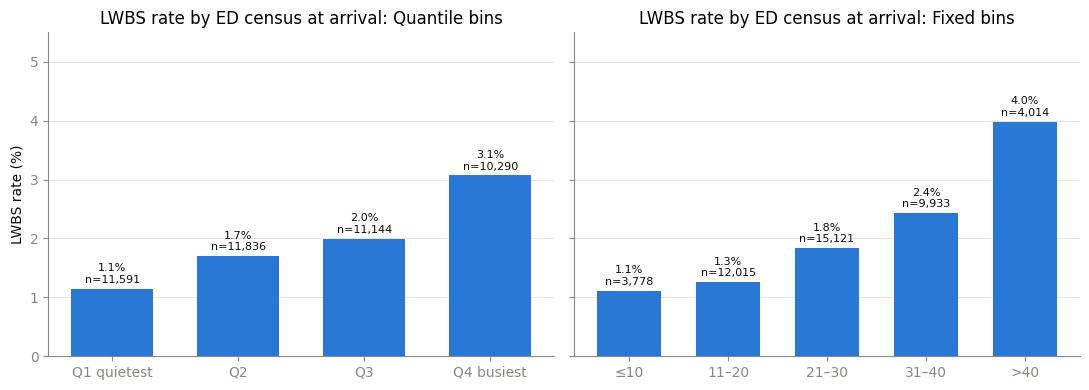

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, title in [(axes[0], "census_q", "Quantile bins"), (axes[1], "census_fixed", "Fixed bins")]:
    g = visits.groupby(col, observed=True)["lwbs"].agg(["mean", "size"])
    ax.bar(g.index.astype(str), g["mean"] * 100, color=BLUE, width=0.65)
    for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, m * 100 + 0.1, f"{m:.1%}\nn={n:,}", ha="center", fontsize=8, color=INK)
    ax.set_title(f"LWBS rate by ED census at arrival: {title}"); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("LWBS rate (%)"); axes[0].set_ylim(0, 5.5)
plt.tight_layout(); plt.show()

Both show the rate rising with crowding, but the fixed bins show *how steeply* at the top end (4% above 40 patients) while the quantile bins average that tail into the top quarter (3%). Quantile bins protect you from tiny groups; fixed bins let extremes speak. Neither is wrong. A reader who only saw the left-hand chart would underestimate what happens on the worst days.

### `KBinsDiscretizer`: binning inside a scikit-learn pipeline

`pd.cut` and `pd.qcut` are for analysis you do by hand. When binning is part of a model's preparation, scikit-learn's `KBinsDiscretizer` does the same job as a fitted transformer, so the edges learned on one dataset are applied unchanged to another. `strategy="quantile"` mirrors `qcut`; `strategy="uniform"` cuts the range into equal widths.

In [15]:
kb = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
kb.fit(visits[["ed_census_at_arrival"]])
print("Edges learned:", np.round(kb.bin_edges_[0], 1))
codes = kb.transform(visits[["ed_census_at_arrival"]])[:, 0].astype(int)
print("Bin codes assigned:", pd.Series(codes).value_counts().sort_index().to_dict())

Edges learned: [ 0. 17. 25. 33. 70.]
Bin codes assigned: {0: 10284, 1: 11583, 2: 11548, 3: 11446}


The learned edges are the same quartiles `qcut` found. The difference is workflow: `kb` can now be handed next year's census values and will place them in this year's bins, which is what you want when comparing periods or when the bins feed a model.

## 6. Putting it together: a model-ready table

A `ColumnTransformer` applies a different preparation to each group of columns and glues the results into one numeric table. Below, each decision from the session is written down in one place:

- `arrival_mode`, `treatment_area`, `disposition_grouped`: nominal → one-hot with a chosen reference.
- `esi_level`: ordinal → one-hot as well (the gaps matter for waiting times), reference ESI 3, the most common level. It is relabelled as text first ("ESI 1" … "ESI 5") so that the encoder cannot mistake it for a number.
- `age`: binned into clinical bands → one-hot, reference 45–64.
- `ems`, `ct_performed`, `arrival_vitals_abnormal`: binary → passed through unchanged.
- `ed_census_at_arrival`: continuous → passed through unchanged (a model can use the number directly).

Rows without a treatment area (LWBS) are excluded, since a model of waiting times can only be built on patients who were seen.

In [16]:
model_rows = visits[visits["provider_datetime"].notna()].copy()
model_rows["age_band"] = pd.cut(model_rows["age"], bins=[17, 44, 64, 79, np.inf], labels=["18-44", "45-64", "65-79", "80+"]).astype(str)
model_rows["esi_label"] = "ESI " + model_rows["esi_level"].astype(int).astype(str)   # text labels: the encoder must not treat ESI as a number

prep = ColumnTransformer(
    transformers=[
        ("mode", OneHotEncoder(categories=[["Private vehicle", "Walk-in", "EMS", "Police"]], drop="first", sparse_output=False), ["arrival_mode"]),
        ("area", OneHotEncoder(categories=[["Main", "Fast track", "Behavioral", "Resuscitation"]], drop="first", sparse_output=False), ["treatment_area"]),
        ("esi", OneHotEncoder(categories=[["ESI 3", "ESI 1", "ESI 2", "ESI 4", "ESI 5"]], drop="first", sparse_output=False), ["esi_label"]),
        ("age", OneHotEncoder(categories=[["45-64", "18-44", "65-79", "80+"]], drop="first", sparse_output=False), ["age_band"]),
        ("flags", "passthrough", ["ems", "ct_performed", "arrival_vitals_abnormal"]),
        ("numeric", "passthrough", ["ed_census_at_arrival"]),
    ],
    verbose_feature_names_out=False,
)
X = prep.fit_transform(model_rows)
design = pd.DataFrame(X, columns=prep.get_feature_names_out(), index=model_rows.index)

print("Model-ready table:", design.shape)
design.head(6).astype(int)

Model-ready table: (43989, 17)


,arrival_mode_Walk-in,arrival_mode_EMS,arrival_mode_Police,treatment_area_Fast track,treatment_area_Behavioral,treatment_area_Resuscitation,esi_label_ESI 1,esi_label_ESI 2,esi_label_ESI 4,esi_label_ESI 5,age_band_18-44,age_band_65-79,age_band_80+,ems,ct_performed,arrival_vitals_abnormal,ed_census_at_arrival
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1
2,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,2
4,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,2
5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
6,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,3


Seventeen numeric columns from six qualitative variables and one count, every column a 0/1 indicator or a plain number, every reference category chosen on purpose. This is the table the regression sessions will start from, with `door_to_provider_min` (or `lwbs`) as the outcome to be explained.

A last word on the reference categories. Each dropped level is the baseline that every other coefficient will be compared with: a walk-in patient's wait *relative to a private-vehicle arrival*, an ESI 4 wait *relative to ESI 3*, an 80+ patient *relative to 45–64*. Choosing the common, clinically neutral level as the reference is what makes the eventual numbers readable to a clinician. That choice was made here, in the encoding, long before any model existed.

## Summary

| Variable kind | Prepare | Encode |
|---|---|---|
| Nominal, few levels | check spellings and level sizes | `OneHotEncoder`, `drop` a chosen reference |
| Nominal, many or rare levels | group rare levels into "Other", or group clinically | then one-hot |
| Ordinal | declare the order (`CategoricalDtype`) | `OrdinalEncoder` if gaps are equal enough; one-hot if not |
| Binary | make the flag (`==`, `isin`) | pass through |
| Continuous, question in bands | `pd.cut` with clinical edges, or `pd.qcut` | then one-hot; `KBinsDiscretizer` inside a pipeline |
| Cyclical | bins that respect the wrap-around | then one-hot |

Three habits. **Classify before you encode**; the kind of variable decides the method. **Choose the reference category on purpose**; it decides how every later number reads. **Prefer cut-points the field already uses**; a bin a clinician recognises is worth more than one that is statistically convenient.